# Spectral Toy Model v2 — Python + JAX Implementation
Ported from MATLAB: spectral_main.m + 6 helper .m files.

All operations are 2D spectral (surface only).
Uses JAX for JIT compilation, GPU acceleration, and auto-differentiation.

In [31]:
import jax
import jax.numpy as jnp
from jax import jit
import jaxopt
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tkinter as tk
from tkinter import filedialog
import scipy.io as sio
import sys


In [32]:
# Input subfiles
from physics_functions import calculate_surface_u, forward_ssh
from cost_functions import cost_function_fmin
from ssh_setup import ssh_setup
# from plotting import plot_surface_fields

# Enable 64-bit precision (critical for matching MATLAB numerics)
jax.config.update("jax_enable_x64", True)


In [33]:
import sys
if "--default" in sys.argv:
    file_path = ""
else:
    print("Select an SSH data file (.mat)... Press Cancel to use default SSH_setup")
    root = tk.Tk()
    root.withdraw()
    
    file_path = filedialog.askopenfilename(
        title="Select an SSH data file (.mat)",
        filetypes=[("MATLAB Data Files", "*.mat"), ("All Files", "*.*")]
    )

use_custom_ssh = False
b_s_custom = None

if file_path:
    mat_contents = sio.loadmat(file_path)
    # Find the relevant array (expecting buoyancy 'bout')
    b_s_data = None
    key = 'bout'
    b_s_data = mat_contents[key]
    b_s_custom = b_s_data[:, :, -1]
    print(f"Loaded 3D buoyancy data from {file_path}, using the last period.")
    # Normalization
    b_s_custom = b_s_custom / jnp.max(jnp.abs(b_s_custom))
    
    Nx, Ny = b_s_custom.shape
    print(f"Grid size adjusted automatically to Nx={Nx}, Ny={Ny}.")
    use_custom_ssh = True
    data_name = os.path.splitext(os.path.basename(file_path))[0]
else:
    # ── Parameters ──
    Nx = 512
    Ny = 512
    case_num = 4  # Change this to try different cases (1–7)
    print(f"Using default SSH setup (Nx=512, Ny=512, Case {case_num}).")
    data_name = f"Default_Case_{case_num}"


Select an SSH data file (.mat)... Press Cancel to use default SSH_setup
Loaded 3D buoyancy data from D:/Documents/College/Research/Oceangrophy/Shafer_Project/SQG_Simulations/Shafer Simulation output/20260320_215523_Shafer_Simulation_random_IC/20260320_215523_Shafer_Simulation_random_IC.mat, using the last period.
Grid size adjusted automatically to Nx=512, Ny=512.


## Set Up Parameters

In [34]:
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Ro = 0.1
Bu = 1.0
f = 1.0
epsilon = Ro
scale = 0.05

# ── Grid Setup (initialize.m) ──
dx = Lx / Nx
dy = Ly / Ny
x = jnp.arange(Nx) * dx
y = jnp.arange(Ny) * dy
X, Y = jnp.meshgrid(x, y, indexing='ij')

# Spectral grid
dk = 2.0 * jnp.pi / Nx
dl = 2.0 * jnp.pi / Ny
k_zonal = jnp.concatenate([jnp.arange(Nx // 2), jnp.arange(-Nx // 2, 0)]) * dk
l_meridional = jnp.concatenate([jnp.arange(Ny // 2), jnp.arange(-Ny // 2, 0)]) * dl
kx, ky = jnp.meshgrid(k_zonal, l_meridional, indexing='ij')

K2 = kx**2 + ky**2
K = jnp.sqrt(K2)

# Safe inverses (avoid division by zero at k=0)
inv_K = jnp.where(K > 0, 1.0 / K, 0.0)
inv_K2 = jnp.where(K2 > 0, 1.0 / K2, 0.0)

mu = jnp.sqrt(Bu) * K
inv_mu = jnp.where(mu > 0, 1.0 / mu, 0.0)

## Initial Surface Sea Height setup
Used shafer simulation or self-writen results.

In [35]:
## Data Processing: Add Filtered White Noise to the true field

b_s_hat = jnp.fft.fft2(b_s_custom)
phi0_s_hat = b_s_hat * inv_mu
phi0_s = jnp.real(jnp.fft.ifft2(phi0_s_hat))

key2 = jax.random.PRNGKey(0)

# Make sure scale is defined
scale = 0.0005

# Add filter to the noise 
noise = jax.random.normal(key2, (Nx, Ny))
noise_hat = jnp.fft.fft2(noise)
# Filter wavenumbers K < 5
noise_hat = jnp.where(K < 5, noise_hat, 0.0)
noise_filtered = jnp.real(jnp.fft.ifft2(noise_hat))

# Add noise to the original field
# phi0_s_true = phi0_s + scale * max_phi0_s * noise_filtered / jnp.max(jnp.abs(noise_filtered))

phi0_s_true = phi0_s + scale * max_phi0_s * noise_filtered
# Go to the spectral space
phi0_s_true_hat = jnp.fft.fft2(phi0_s_true)
phi0_s_hat = jnp.fft.fft2(phi0_s)


# Plotting Original and True Field
In this plot I plot the vorticity from the original field and the true field then compare them. To see if the perturbation is physical

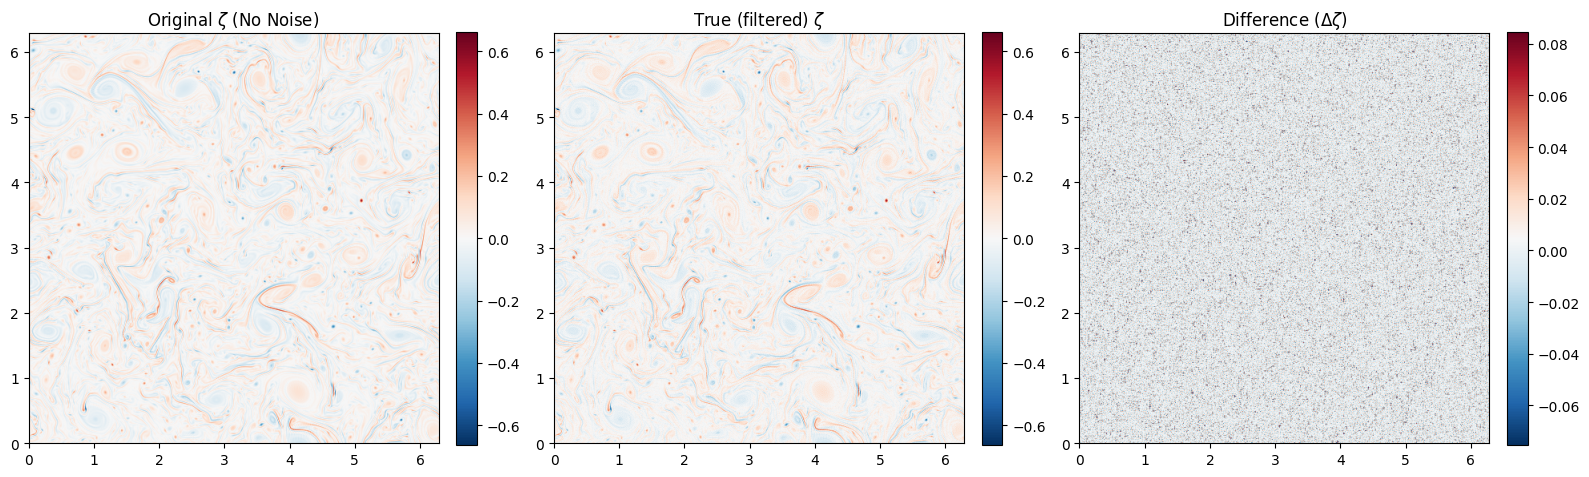

In [36]:
from physics_functions import calculate_surface_u
import matplotlib.pyplot as plt

# 1. Compute velocity fields
u_ori, v_ori = calculate_surface_u(phi0_s_hat, mu, inv_mu, kx, ky, K2, inv_K2, epsilon, Bu)
u_true, v_true = calculate_surface_u(phi0_s_true_hat, mu, inv_mu, kx, ky, K2, inv_K2, epsilon, Bu)

# 2. Compute vorticity (dv/dx - du/dy) in spectral space
u_ori_hat = jnp.fft.fft2(u_ori)
v_ori_hat = jnp.fft.fft2(v_ori)
u_true_hat = jnp.fft.fft2(u_true)
v_true_hat = jnp.fft.fft2(v_true)

zeta_ori = jnp.real(jnp.fft.ifft2(1j * kx * v_ori_hat - 1j * ky * u_ori_hat))
zeta_true = jnp.real(jnp.fft.ifft2(1j * kx * v_true_hat - 1j * ky * u_true_hat))

# 3. Plotting comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Make sure min/max scales match for visual comparison
vmax = max(jnp.max(jnp.abs(zeta_ori)), jnp.max(jnp.abs(zeta_true)))
vmin = -vmax

# Original Vorticity
im0 = axes[0].imshow(zeta_ori, cmap='RdBu_r', origin='lower', extent=[0, float(Lx), 0, float(Ly)], vmin=vmin, vmax=vmax)
axes[0].set_title(r"Original $\zeta$ (No Noise)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Noisy Vorticity
im1 = axes[1].imshow(zeta_true, cmap='RdBu_r', origin='lower', extent=[0, float(Lx), 0, float(Ly)], vmin=vmin, vmax=vmax)
axes[1].set_title(r"True (filtered) $\zeta$")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Difference
im2 = axes[2].imshow(zeta_true - zeta_ori, cmap='RdBu_r', origin='lower', extent=[0, float(Lx), 0, float(Ly)])
axes[2].set_title(r"Difference ($\Delta\zeta$)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# Forward Part

In [ ]:
# ── Forward Part: Generate True SSH ──
eta_s_hat_true = forward_ssh(phi0_s_true_hat, f, kx, ky, mu, inv_mu, K2, inv_K2, Bu, epsilon)
print("True SSH data generated")    

cost_function_fmin(phi0_s, f, kx, ky, mu, inv_mu, Bu, epsilon, K2, inv_K2, eta_s_hat_true)

True SSH data generated


Array(460500.7462844, dtype=float64)

# Inversion Part

In [ ]:
# ── Inversion Part ──
# max_phi0_s = jnp.max(phi0_s)
# key2 = jax.random.PRNGKey(0)
# phi0_s_guess = phi0_s + 0.001 * max_phi0_s * jax.random.normal(key2, (Nx, Ny))

# start with the true field
phi0_s_guess = phi0_s
# ===================== Optimization Settings =====================
num_iterations = 300000

# Build JIT‑compiled cost and gradient (fminunc style)
@jit
def loss_fn(phi0_s_flat):
    phi0_s_2d = phi0_s_flat.reshape(Nx, Ny)
    return cost_function_fmin(
        phi0_s_2d, f, kx, ky, mu, inv_mu, Bu, epsilon, K2, inv_K2, eta_s_hat_true
    )

# Compute the gradient for the loss function
grad_fn = jit(jax.grad(loss_fn))

# Use L‑BFGS (matches MATLAB's fminunc quasi‑newton)
solver = jaxopt.LBFGS(
    fun=loss_fn,
    maxiter=num_iterations,
    tol=1e-8,
)

print(f"Running optimization: LBFGS (auto‑diff gradients, {Nx}x{Ny})")
t0 = time.time()

phi0_flat_guess = phi0_s_guess.ravel()

# ── Option B: Manual loop with early stopping + logging ──
state = solver.init_state(phi0_flat_guess)
params = phi0_flat_guess

for i in range(num_iterations):
    params, state = solver.update(params, state)
    loss_val = float(loss_fn(params))
    g_norm = float(jnp.linalg.norm(grad_fn(params)))
    if (i + 1) % 100 == 0 or i == 0:
        print(f"  Iter {i+1:4d} | Loss = {loss_val:.6e} | |grad| = {g_norm:.6e}")
    if loss_val < 1e-8:
        print(f"  Converged at iter {i+1} (Loss = {loss_val:.6e})")
        break

elapsed = time.time() - t0
print(f"Optimization Complete. Elapsed: {elapsed:.2f}s")

phi0_s_opt = params.reshape(Nx, Ny)

# ── Calculate Pure QG field ──
phi_qg_hat = eta_s_hat_true / f
u_qg = jnp.real(jnp.fft.ifft2(-1j * ky * phi_qg_hat))
v_qg = jnp.real(jnp.fft.ifft2( 1j * kx * phi_qg_hat))
zeta_qg = jnp.real(jnp.fft.ifft2(1j * kx * v_qg - 1j * ky * u_qg))


# Save Data and Plot

In [ ]:
# ── Save Data to Run Folder ──
import glob

SAVE_DATA = True

if SAVE_DATA:
    base_output = r"D:\Documents\College\Research\Oceangrophy\Shafer_Project\Output"
    data_dir = os.path.join(base_output, data_name)
    os.makedirs(data_dir, exist_ok=True)

    # Determine run number (increment based on existing run_* folders)
    existing_runs = sorted(glob.glob(os.path.join(data_dir, "run_*")))
    run_num = len(existing_runs) + 1
    run_dir = os.path.join(data_dir, f"run_{run_num}")
    os.makedirs(run_dir)
else:
    run_dir = None


# Save Log in log file

In [ ]:
# Save potentials and parameters
if SAVE_DATA:
    np.savez(
        os.path.join(run_dir, "potentials.npz"),
        phi0_s_opt=np.array(phi0_s_opt),
        phi0_s_true=np.array(phi0_s_true),
        phi0_s_ori = np.array(phi0_s),
        eta_s_hat_true=np.array(eta_s_hat_true),
        u_qg=np.array(u_qg), v_qg=np.array(v_qg),
        x=np.array(x), y=np.array(y),
        kx=np.array(kx), ky=np.array(ky),
        mu=np.array(mu), inv_mu=np.array(inv_mu),
        K2=np.array(K2), inv_K2=np.array(inv_K2),
        epsilon=float(epsilon), Bu=float(Bu),
        Nx=Nx, Ny=Ny, elapsed=elapsed,
    )
    print(f"Data saved to {run_dir}")

    # ── Generate Run Summary Markdown ──
    from datetime import datetime
    summary_path = os.path.join(run_dir, "run_summary.md")
    with open(summary_path, "w") as md:
        md.write(f"# Run {run_num} Summary\n\n")
        md.write(f"**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        md.write(f"## Data Source\n")
        md.write(f"- **Simulation name:** `{data_name}`\n")
        md.write(f"- **Custom SSH file:** `{file_path if file_path else 'N/A (default case)'}`\n\n")
        md.write(f"## Grid Parameters\n")
        md.write("|Parameter|Value|\n")
        md.write("|---|---|\n")
        md.write(f"| Nx | {Nx} |\n")
        md.write(f"| Ny | {Ny} |\n")
        md.write(f"| Lx | {float(Lx):.4f} |\n")
        md.write(f"| Ly | {float(Ly):.4f} |\n\n")
        md.write(f"## Physical Parameters\n")
        md.write("|Parameter|Value|\n")
        md.write("|---|---|\n")
        md.write(f"| Ro (Rossby) | {float(Ro)} |\n")
        md.write(f"| Bu (Burger) | {float(Bu)} |\n")
        md.write(f"| f (Coriolis) | {float(f)} |\n")
        md.write(f"| epsilon | {float(epsilon)} |\n")
        md.write(f"| scale (noise) | {float(scale)} |\n\n")
        md.write(f"## Optimization Settings\n")
        md.write("|Parameter|Value|\n")
        md.write("|---|---|\n")
        md.write(f"| Solver | L-BFGS (jaxopt) |\n")
        md.write(f"| Max iterations | {num_iterations} |\n")
        md.write(f"| Tolerance (tol) | {solver.tol:.1e} |\n")
        md.write(f"| Convergence cutoff (loss) | 1e-8 |\n")
        md.write(f"| Final loss | {loss_val:.6e} |\n")
        md.write(f"| Final |grad| | {g_norm:.6e} |\n")
        md.write(f"| Converged iter | {i+1} |\n")
        md.write(f"| Elapsed time | {elapsed:.2f}s |\n\n")
    print(f"Run summary saved to {summary_path}")


# The following allows directly loading output files without running the codes once againi.

In [ ]:
# Import data 
npz_path = r"D:\Documents\College\Research\Oceangrophy\Shafer_Project\Output\20260327_231933_Shafer_Simulation_random_IC\run_5\potentials.npz"

data = np.load(npz_path, allow_pickle=True)
phi0_s_ori  = jnp.array(data["phi0_s_ori"])

# ── Display data structure ──
print(f"{'Key':<20} {'dtype':<12} {'shape'}")
print("-" * 50)
for key in data.files:
    arr = data[key]
    if hasattr(arr, 'shape') and arr.shape:
        print(f"{key:<20} {str(arr.dtype):<12} {arr.shape}")
    else:
        print(f"{key:<20} {'scalar':<12} {arr.item()}")

In [ ]:
import importlib
importlib.reload(plotting)

In [ ]:
import plotting
plotting.SAVE_OUTPUT = False  # don't save during testing

ctx = plotting.prepare_surface_fields(phi0_s_opt, phi0_s_true, phi0_s_ori, u_qg, v_qg, zeta_qg, x, y,
                           kx, ky, mu, inv_mu, K2, inv_K2, epsilon, Bu,
                           Nx, Ny, elapsed, run_dir)





Plot one at a time in separate cells:

In [ ]:
# For true and original comparison
plotting.plot_ori_vs_true_zeta(ctx)

In [ ]:

plotting.plot_surface_u(ctx)

In [ ]:
plotting.plot_surface_zeta(ctx)


In [ ]:
plotting.plot_qg_vs_sqg_u(ctx)


In [ ]:
plotting.plot_qg_vs_sqg_zeta(ctx)